# Statistical Inference on U.S. Video Game Sales (2004–2010)

**Shaurya Ghai, Granth Bangard**

Part 2 of 3 — Confidence Intervals & Hypothesis Testing

## 1. Introduction

### Dataset
This notebook continues analysis of the Video Games Sales dataset: 1,770 commercially notable titles released in the U.S. between 2004–2010, curated by Dr. Joe Cox (University of Portsmouth Research Portal).

### Population vs. Sample
This dataset is a sample — it cannot capture every game released in the U.S. during this period, particularly smaller indie titles. Our population of interest is: *all commercially notable video games released in the United States from 2004–2010.*

### Research Questions
1. **Confidence Interval:** What proportion of notable U.S. video games released between 2004–2010 included online features?
2. **Hypothesis Test:** Is the true mean U.S. sales of a commercially notable video game from this era greater than 0.3 million copies?

### Contextual Importance
Estimating the proportion of online-enabled games helps trace the growth of online gaming before it became ubiquitous. Understanding whether the average commercially notable game exceeded 0.3M in sales contextualizes industry performance benchmarks for this era.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('video_games.csv', encoding='unicode-escape')
print(df.shape)

(1770, 166)


## 2. Confidence Interval: Proportion of Games with Online Features

### Research Question
What proportion of commercially notable U.S. video games released between 2004–2010 included online features?

In [2]:
# Encode Online as boolean
df['Online'] = df['Online'].astype(bool)

# Check for missing values and value distribution
print('Missing values in Online:', df['Online'].isna().sum())
print()
df['Online'].value_counts()

Missing values in Online: 0



False    1143
True      627
Name: Online, dtype: int64

No missing values. Only True/False values present — no implicit missing values. We assumed standard 0/1 encoding (0 = no online features, 1 = has online features).

In [3]:
n = len(df)
sample_prop = df['Online'].mean()
print(f'Sample size: {n}')
print(f'Sample proportion (p_hat): {sample_prop:.4f}')
print(f'{sample_prop*100:.1f}% of games in our sample had online features')

Sample size: 1770
Sample proportion (p_hat): 0.3542
35.4% of games in our sample had online features


### Bootstrap Confidence Interval (95%)

95% Confidence Interval: [0.332, 0.377]


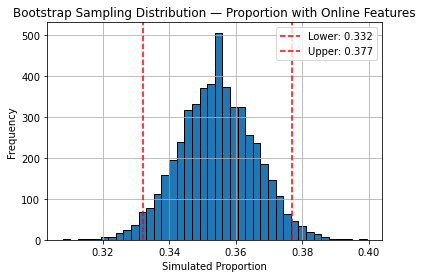

In [4]:
simulated_stat = []
for i in range(5000):
    sample_df = df.sample(n=n, replace=True)
    simulated_stat.append(sample_df['Online'].mean())

sampling_df = pd.DataFrame({'x': simulated_stat})

lower = sampling_df['x'].quantile(0.025)
upper = sampling_df['x'].quantile(0.975)
print(f'95% Confidence Interval: [{lower:.3f}, {upper:.3f}]')

sampling_df['x'].hist(bins=40, edgecolor='black')
plt.axvline(lower, color='red', linestyle='--', label=f'Lower: {lower:.3f}')
plt.axvline(upper, color='red', linestyle='--', label=f'Upper: {upper:.3f}')
plt.xlabel('Simulated Proportion')
plt.ylabel('Frequency')
plt.title('Bootstrap Sampling Distribution — Proportion with Online Features')
plt.legend()
plt.show()

### Interpretation
We are 95% confident that the true population proportion of commercially notable U.S. video games released between 2004–2010 that included online features lies between **0.332 and 0.377**.

This means that roughly one-third of commercially notable games from this era had online features — notable given how dominant online gaming is today, and useful for tracing when the shift toward online-first game design began.

## 3. Hypothesis Test: Is True Mean U.S. Sales Greater Than 0.3 Million?

### Research Question
Is the true mean U.S. sales of a commercially notable video game released between 2004–2010 greater than 0.3 million copies?

### Hypotheses
- **H0:** mu = 0.3 (true mean U.S. sales is 0.3 million copies)
- **Ha:** mu > 0.3 (true mean U.S. sales is greater than 0.3 million)
- **Significance level:** alpha = 0.05

We chose 0.3M as the null value because it represents a reasonable baseline for a moderately successful commercial release in this era.

In [5]:
df_sales = df[['US Sales (millions)']].dropna()
print('Sample size:', len(df_sales))
print('Any negative values:', (df_sales['US Sales (millions)'] < 0).sum())
df_sales['US Sales (millions)'].describe()

Sample size: 1770
Any negative values: 0


count    1770.000000
mean        0.479785
std         1.064915
min         0.010000
25%         0.090000
50%         0.190000
75%         0.450000
max        14.660000
Name: US Sales (millions), dtype: float64

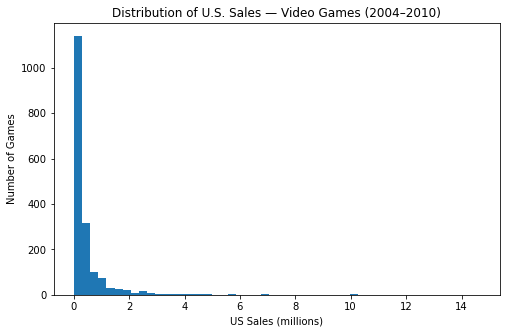

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df_sales['US Sales (millions)'], bins=50)
plt.xlabel('US Sales (millions)')
plt.ylabel('Number of Games')
plt.title('Distribution of U.S. Sales — Video Games (2004–2010)')
plt.show()

The distribution is heavily right-skewed. Most games sold under 1M copies, while a few blockbuster titles sold significantly more. The mean (0.48M) is well above the median (0.19M), confirming the skew.

**Conditions for the test:**
1. *Random sample:* Dataset is treated as representative of commercially notable titles
2. *Independence:* Each game's sales is independent; sample is under 10% of the population
3. *Sample size:* n = 1,770 — large enough for CLT to apply despite the right-skew

In [7]:
observed_mean = df_sales['US Sales (millions)'].mean()
null_value = 0.3
print(f'Observed sample mean: {observed_mean:.4f} million copies')
print(f'Null value: {null_value}')

Observed sample mean: 0.4798 million copies
Null value: 0.3


In [8]:
# Simulate sampling distribution under H₀ by shifting data
df_shifted = df_sales['US Sales (millions)'] - observed_mean + null_value

simulated_means = []
for i in range(5000):
    boot_sample = df_shifted.sample(n=len(df_sales), replace=True)
    simulated_means.append(boot_sample.mean())

sampling_df2 = pd.DataFrame({'x': simulated_means})

p_value = (sampling_df2['x'] >= observed_mean).mean()
print(f'Observed mean: {observed_mean:.4f}')
print(f'P-value: {p_value}')

Observed mean: 0.4798
P-value: 0.0


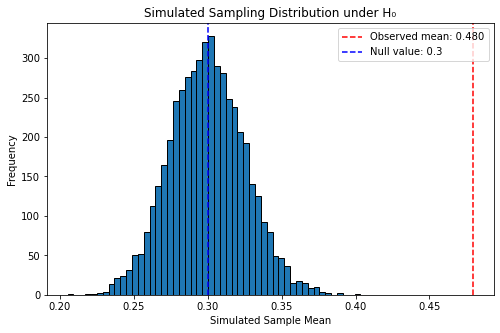

In [9]:
plt.figure(figsize=(8, 5))
sampling_df2['x'].hist(bins=50, edgecolor='black')
plt.axvline(observed_mean, color='red', linestyle='--', label=f'Observed mean: {observed_mean:.3f}')
plt.axvline(null_value, color='blue', linestyle='--', label=f'Null value: {null_value}')
plt.xlabel('Simulated Sample Mean')
plt.ylabel('Frequency')
plt.title('Simulated Sampling Distribution under H₀')
plt.legend()
plt.grid(False)
plt.show()

### Decision and Conclusion
Our p-value is approximately 0, meaning it would be essentially impossible to observe a sample mean of 0.48M or greater by random chance if the true mean were 0.3M.

Since p-value < alpha = 0.05, we **reject the null hypothesis**. There is sufficient evidence to conclude that the true mean U.S. sales of commercially notable video games released between 2004–2010 exceeded 0.3 million copies.

## 4. Conclusion

### Summary
We conducted two inference tasks on U.S. video game sales from 2004–2010:

**Confidence Interval:** Our sample proportion of games with online features was 0.354. Using bootstrap resampling, we estimated the true population proportion lies between 0.332 and 0.377 (95% confidence).

**Hypothesis Test:** With an observed sample mean of 0.48M copies and a simulated p-value of approximately 0, we rejected the null hypothesis. There is strong evidence that the true mean U.S. sales for commercially notable games from this era exceeded 0.3M copies.

### Limitations
- Dataset excludes smaller indie titles, likely inflating sales estimates
- Heavy right-skew means the mean is pulled up by a few blockbusters — median (0.19M) better represents the typical game
- Online variable encoding assumed standard 0/1 convention without official documentation

### Next Steps
Comparing mean sales between online and non-online games with a two-sample hypothesis test, and examining whether the proportion of online-enabled games grew year-over-year from 2004–2010. See Notebook 3 for predictive modeling.